In [2]:
# Exploratory Data Analysis
# Load all the cleaned datasets
import pandas as pd 
customers =pd.read_csv("customers_dataset_cleaned.csv")
orders=pd.read_csv("orders_dataset_cleaned.csv")
order_items=pd.read_csv("orders_items_dataset_cleaned.csv")
payments=pd.read_csv("orders_payments_dataset_cleaned.csv")
reviews=pd.read_csv("orders_reviews_dataset_cleaned.csv")
products=pd.read_csv("products_dataset_cleaned.csv")
sellers=pd.read_csv("sellers_dataset_cleaned.csv")
geolocation=pd.read_csv("geolocation_dataset_unique.csv")


In [6]:
# verify the load 
print(customers.shape)
print(orders.shape)
print(order_items.shape)

(99441, 5)
(99441, 8)
(112650, 7)


In [7]:
# Customers Dataset Exploration 
# Goal : Understand customer distribution and order frequency
# Inspect the structure 
customers.info()
customers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [8]:
# Count Unique Customers
customers['customer_id'].nunique()

99441

In [9]:
# Distribution by zip prefix 
customers['customer_zip_code_prefix'].value_counts().head(10)

customer_zip_code_prefix
22790    142
24220    124
22793    121
24230    117
22775    110
29101    101
13212     95
35162     93
22631     89
38400     87
Name: count, dtype: int64

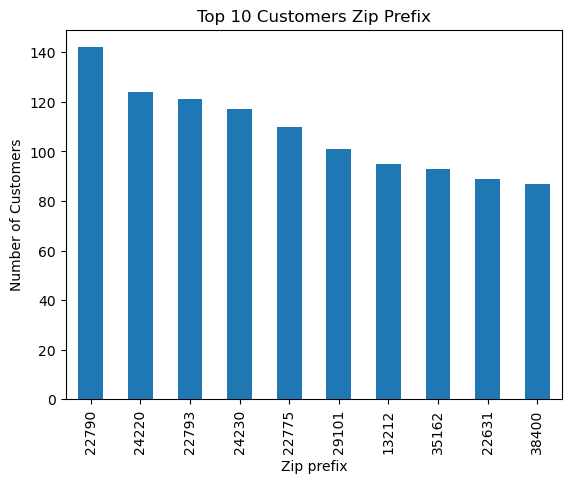

In [11]:
# Visualization 
import matplotlib.pyplot as plt
customers['customer_zip_code_prefix'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Customers Zip Prefix')
plt.xlabel("Zip prefix")
plt.ylabel("Number of Customers")
plt.show()

In [12]:
# Orders Dataset Exploration 
# Goal: Understand the order life cycle- statuses, approval times, and delivery times.
# Inspect the structure
orders.info()
orders.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20
freq,1,1,96478,3,9,47,3,522


In [13]:
# Order status Distribution
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [14]:
# Delivery Time Calculation 
orders['delivery_time_days']=(
    pd.to_datetime(orders['order_delivered_customer_date'])-
    pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days
orders['delivery_time_days'].describe()
    

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

In [17]:
# Approval Time Calculation 
orders['approval_time_minutes']=(
pd.to_datetime(orders['order_approved_at'])-
pd.to_datetime(orders['order_purchase_timestamp'])
).dt.total_seconds()/60
orders['approval_time_minutes'].describe()


count     99281.000000
mean        625.145658
std        1562.280218
min           0.000000
25%          12.900000
50%          20.600000
75%         874.850000
max      270550.833333
Name: approval_time_minutes, dtype: float64

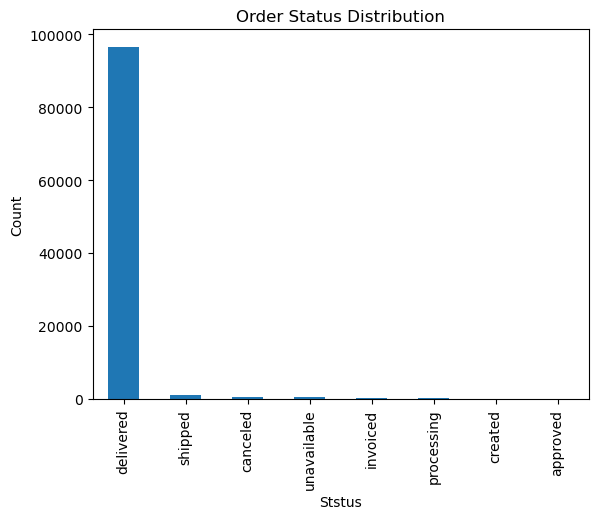

In [19]:
# Visualizations 
orders['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Ststus")
plt.ylabel("Count")
plt.show()

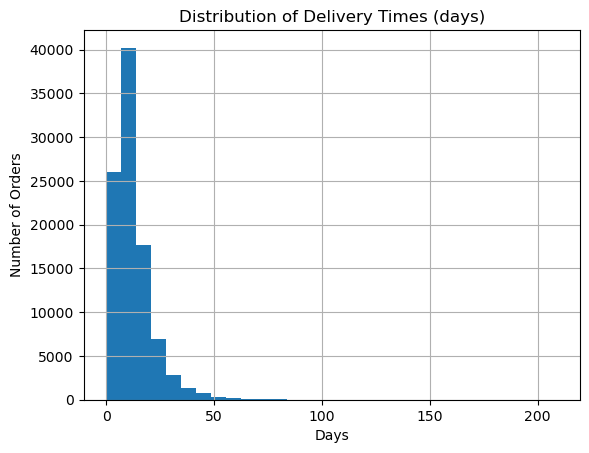

In [20]:
# Delivery Time Histogram
orders['delivery_time_days'].dropna().hist(bins=30)
plt.title("Distribution of Delivery Times (days)")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()

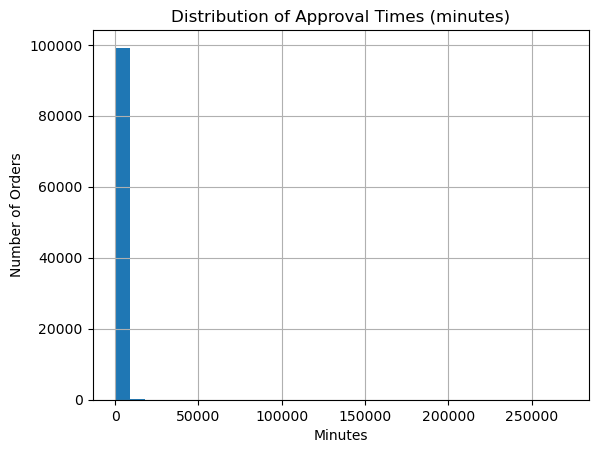

In [21]:
# Approval time Histogram 
orders['approval_time_minutes'].dropna().hist(bins=30)
plt.title("Distribution of Approval Times (minutes)")
plt.xlabel("Minutes")
plt.ylabel("Number of Orders")
plt.show()

In [22]:
# Order Items Dataset Exploration 
# Goal: Understand product quantities, frieght values and seller relationships 
# Inspect the Structure
order_items.info()
order_items.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [23]:
# Top Products by Frequency 
order_items['product_id'].value_counts().head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64

In [24]:
# Freight Value Distribution 
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [26]:
# Average Items per Order
order_items.groupby('order_id')['order_item_id'].count().mean()

1.1417306873695092

In [27]:
# Link sellers to orders
order_items['seller_id'].nunique()

3095

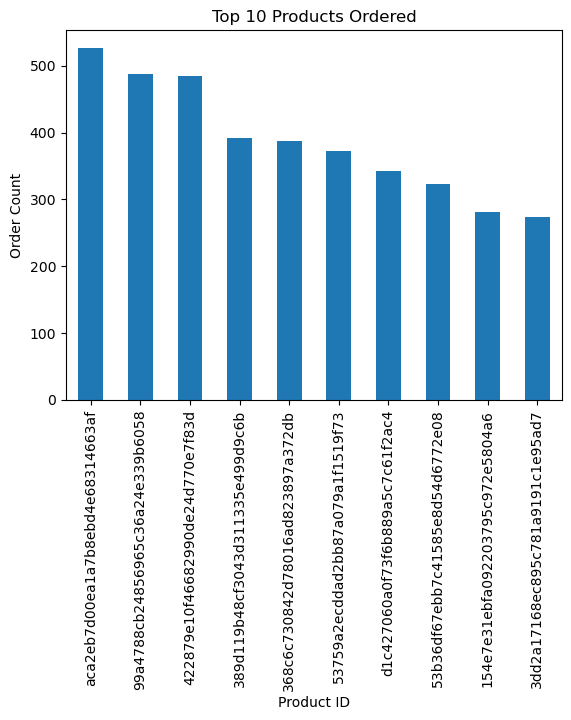

In [29]:
# Visualization 
# Top 10 products by frequency
order_items['product_id'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Products Ordered")
plt.xlabel("Product ID")
plt.ylabel("Order Count")
plt.show()

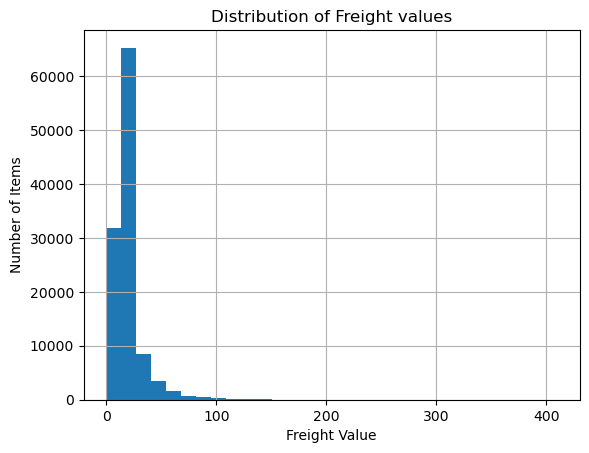

In [30]:
# Freight value histogram
order_items['freight_value'].dropna().hist(bins=30)
plt.title("Distribution of Freight values")
plt.xlabel("Freight Value")
plt.ylabel("Number of Items")
plt.show()

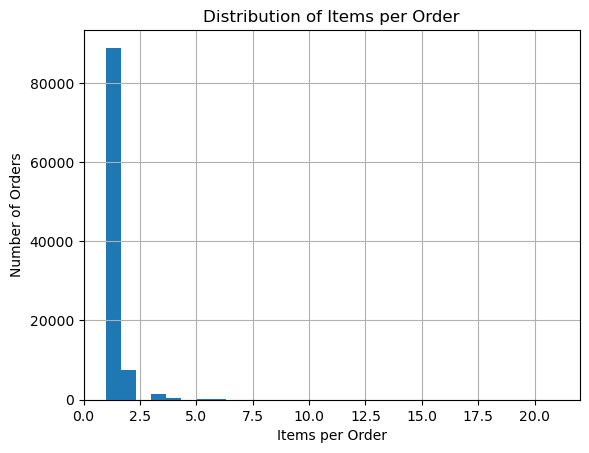

In [33]:
# Items per order distribution 
order_items.groupby('order_id')['order_item_id'].count().hist(bins=30)
plt.title("Distribution of Items per Order")
plt.xlabel("Items per Order")
plt.ylabel("Number of Orders")
plt.show()

In [3]:
# Payments Dataset Exploration
# Goal: Understand payment methods, installment patterns, and anomalies
# Inspect structure
payments.info()
payments.describe(include='all')
payments['payment_type'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [4]:
# Payment methods distribution 
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [7]:
# Installment Patterns 
payments['payment_installments'].value_counts()
payments.groupby('payment_installments')['payment_value'].mean()

payment_installments
0      94.315000
1     112.420229
2     127.228150
3     142.539317
4     163.976840
5     183.465222
6     209.849952
7     187.673672
8     307.737427
9     203.440870
10    415.085837
11    124.932174
12    321.678496
13    150.462500
14    167.962667
15    445.553108
16    292.694000
17    174.602500
18    486.483333
20    615.801765
21    243.700000
22    228.710000
23    236.480000
24    610.048889
Name: payment_value, dtype: float64

In [8]:
# anomaly detection (outliers, failed transactions)
import numpy as np 
z_scores=np.abs((payments['payment_value']-payments['payment_value'].mean())/payments['payment_value'].std())

NameError: name 'plt' is not defined

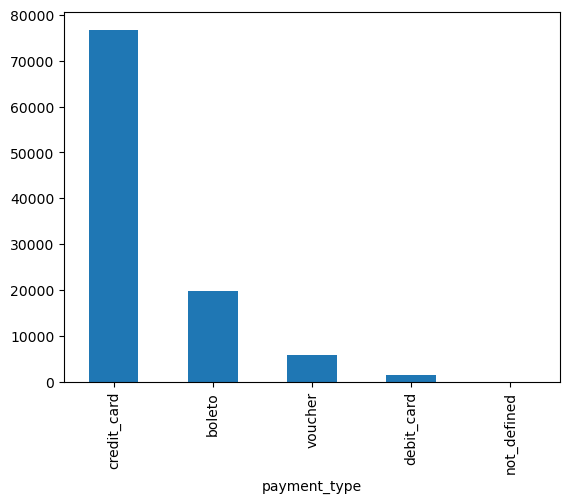

In [9]:
# Visualizations 
# Payment methods bar chart 
payments['payment_type'].value_counts().plot(kind='bar')
plt.title("Payment Methods Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.show()

NameError: name 'plt' is not defined

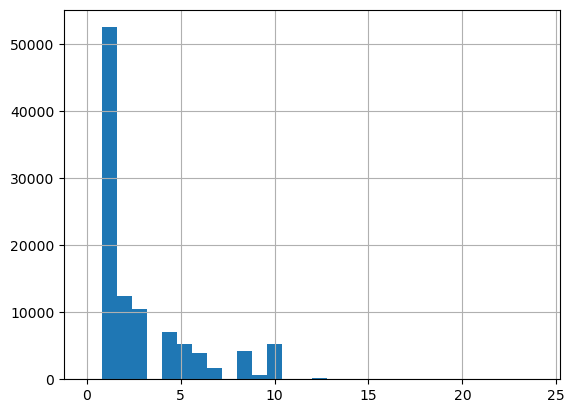

In [11]:
# Installment Histogram
payments['payment_installments'].hist(bins=30)
plt.title("Distribution of Installments")
plt.xlabel("Installments")
plt.ylabel("Number of Payments")
plt.show()

NameError: name 'plt' is not defined

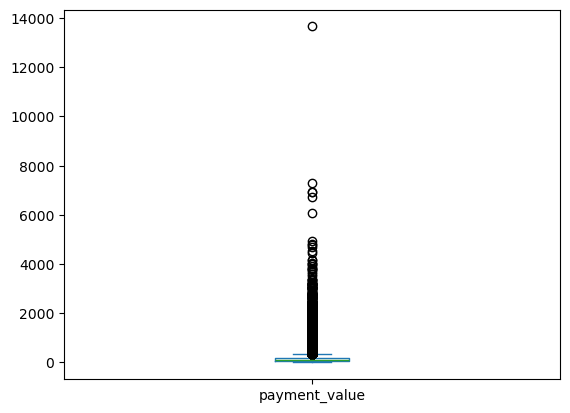

In [13]:
# Payment Value Boxplot
payments['payment_value'].plot(kind='box')
plt.title("Payment Value Outliers")
plt.show()

In [14]:
# Reviews dataset Exploration
# Goal: Analyze review scores, text behavior, and sentiment patterns to understand customer satisfaction
# Inspect structure 
reviews.info()
reviews.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     99224 non-null  object
 4   review_comment_message   99224 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
 7   review_answer-timestamp  99224 non-null  object
dtypes: int64(1), object(7)
memory usage: 6.1+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_answer-timestamp
count,99224,99224,99224.000000,99224,99224,99224,99224,99224
unique,98410,98673,NaN,4528,36160,636,98248,98248
top,7b606b0d57b078384f0b58eac1d41d78,c88b1d1b157a9999ce368f218a407141,NaN,No Title,No Comment,2017-12-19 00:00:00,2017-06-15 23:21:05,2017-06-15 23:21:05
freq,3,3,NaN,87656,58247,463,4,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN


In [15]:
# Review score distribution 
reviews['review_score'].value_counts()
reviews['review_score'].value_counts(normalize=True)* 100

review_score
5    57.776344
4    19.291704
1    11.513344
3     8.242965
2     3.175643
Name: proportion, dtype: float64

In [16]:
# Missing text analysis 
reviews[['review_comment_title','review_comment_message']].isnull()

,review_comment_title,review_comment_message
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
99219,False,False
99220,False,False
99221,False,False
99222,False,False


In [17]:
# Average Score per Order 
reviews.groupby('order_id')['review_score'].mean()

order_id
00010242fe8c5a6d1ba2dd792cb16214    5.0
00018f77f2f0320c557190d7a144bdd3    4.0
000229ec398224ef6ca0657da4fc703e    5.0
00024acbcdf0a6daa1e931b038114c75    4.0
00042b26cf59d7ce69dfabb4e55b4fd9    5.0
                                   ... 
fffc94f6ce00a00581880bf54a75a037    5.0
fffcd46ef2263f404302a634eb57f7eb    5.0
fffce4705a9662cd70adb13d4a31832d    5.0
fffe18544ffabc95dfada21779c9644f    5.0
fffe41c64501cc87c801fd61db3f6244    5.0
Name: review_score, Length: 98673, dtype: float64

NameError: name 'plt' is not defined

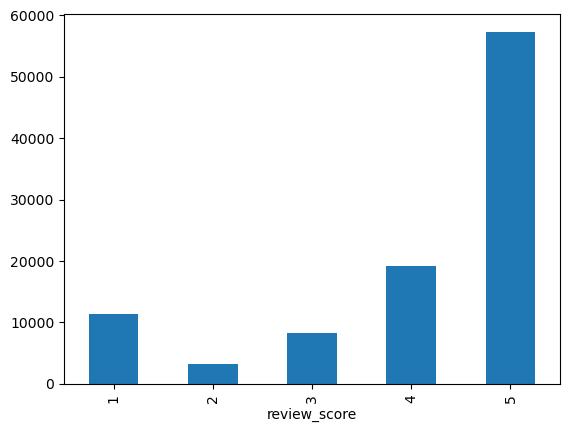

In [20]:
# Visualizations 
#review score distribution (barchart)
reviews['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title("Review Score Distrinution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

NameError: name 'plt' is not defined

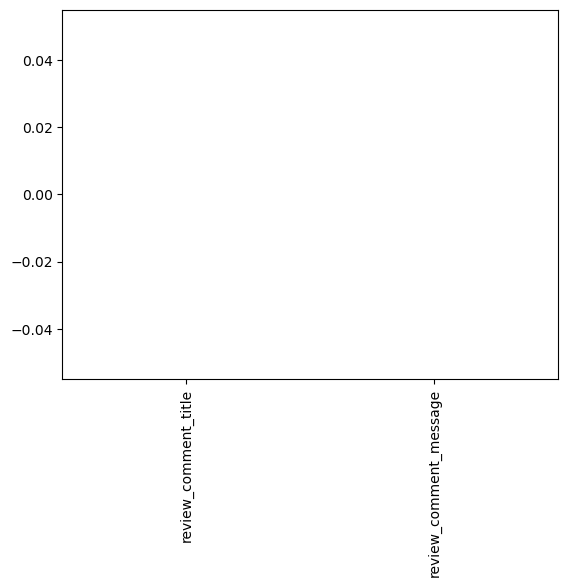

In [21]:
# Missing Text Visualization 
reviews[['review_comment_title','review_comment_message']].isnull().sum().plot(kind='bar')
plt.title("Missing Review Text Fields")
plt.show()

In [23]:
# Delivery Time vs Review Score (boxplot)
merged.boxplot(column='delivery_time_days', by='review_score')
plt.title("Delivery Time Vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Time (days)")
plt.show()

NameError: name 'merged' is not defined

In [24]:
merged = reviews.merge(
    orders[['order_id','delivery_time_days']], 
    on='order_id', 
    how='left'
)


KeyError: "['delivery_time_days'] not in index"

In [25]:
orders['delivery_time_days'] = (
    pd.to_datetime(orders['order_delivered_customer_date']) - 
    pd.to_datetime(orders['order_purchase_timestamp'])
).dt.days


In [26]:
merged = reviews.merge(
    orders[['order_id','delivery_time_days']], 
    on='order_id', 
    how='left'
)


NameError: name 'plt' is not defined

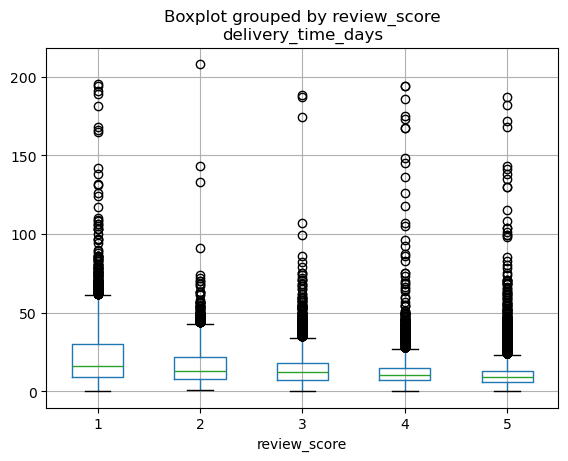

In [27]:
merged.boxplot(column='delivery_time_days', by='review_score')
plt.title("Delivery Time vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Time (days)")
plt.show()


In [29]:
# Product Dataset Exploration 
# Goal : Analyze product categories, dimensions, and detect anomalies in product attributes 
# Inspect structure
products.info()
products.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
 9   product-category_name       32951 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product-category_name
count,32951,32951,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951.000000,32951
unique,32951,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,cama_mesa_banho
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3029
mean,NaN,NaN,47.579527,757.213104,2.148463,2276.334315,30.813207,16.936633,23.195320,NaN
std,NaN,NaN,12.071951,637.745057,1.745732,4281.945502,16.915648,13.637779,12.080033,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,41.000000,326.000000,1.000000,300.000000,18.000000,8.000000,15.000000,NaN
50%,NaN,NaN,51.000000,584.000000,1.000000,700.000000,25.000000,13.000000,20.000000,NaN
75%,NaN,NaN,57.000000,961.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,NaN


In [30]:
# Top product categories 
products['product_category_name'].value_counts().head(10)


product_category_name
cama_mesa_banho           3029
esporte_lazer             2867
moveis_decoracao          2657
beleza_saude              2444
utilidades_domesticas     2335
automotivo                1900
informatica_acessorios    1639
brinquedos                1411
relogios_presentes        1329
telefonia                 1134
Name: count, dtype: int64

In [31]:
# Missing Values Check
products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
product-category_name         0
dtype: int64

In [33]:
# Numeric Attributes(dimension and weight)
products[['product_weight_g', 'product_length_cm','product_height_cm','product_width_cm']].describe()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951.000000,32951.000000,32951.000000,32951.000000
mean,2276.334315,30.813207,16.936633,23.195320
std,4281.945502,16.915648,13.637779,12.080033
min,0.000000,0.000000,0.000000,0.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [34]:
# Detect anomalies (e.g., zero or negative values
products[(products['product_weight_g'] <= 0) | 
         (products['product_length_cm'] <= 0) | 
         (products['product_height_cm'] <= 0) | 
         (products['product_width_cm'] <= 0)]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product-category_name
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,0.0,0.0,0.0,0.0,bebes
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0,cama_mesa_banho
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0,cama_mesa_banho
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0,cama_mesa_banho
18851,5eb564652db742ff8f28759cd8d2652a,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Unknown
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0,cama_mesa_banho


In [36]:
# Visualizations 
# Top 10 product categories 
products['product_category_name'].value_counts().head(10)
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

NameError: name 'plt' is not defined

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt


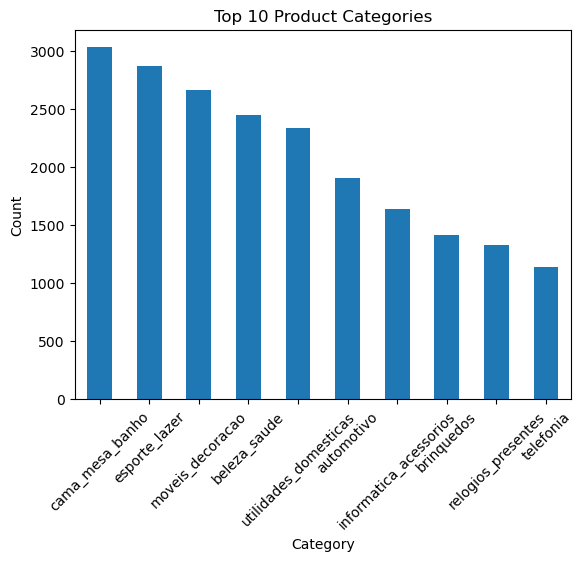

In [38]:
products['product_category_name'].dropna().value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [39]:
# sellers dataset exploration 
# Goal: Analyze seller distribution, activity levels, and geogrpahic spread
# Inspect the Structure 
sellers.info()
sellers.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   object
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095,3095,3095
unique,3095,1416,611,23
top,3442f8959a84dea7ee197c632cb2df15,Unknown,sao paulo,SP
freq,1,1027,694,1849


In [40]:
# Unique sellers count 
sellers['seller_id'].nunique()

3095

In [41]:
# Top Seller zip prefixes 
sellers['seller_zip_code_prefix'].value_counts().head(10)

seller_zip_code_prefix
Unknown    1027
14940        49
13660        10
16200         9
13920         9
87050         8
14020         8
13481         7
37540         7
18015         6
Name: count, dtype: int64

In [46]:
# Check the anomalies 
sellers[sellers['seller_zip_code_prefix'].isnull()]
sellers[sellers['seller_zip_code_prefix']< 10000]

TypeError: '<' not supported between instances of 'str' and 'int'

In [47]:
# Convert to numeric, forcing errors to NaN
sellers['seller_zip_code_prefix'] = pd.to_numeric(sellers['seller_zip_code_prefix'], errors='coerce')

# Now check for anomalies
invalid_zips = sellers[sellers['seller_zip_code_prefix'] < 10000]
print(invalid_zips.head())


Empty DataFrame
Columns: [seller_id, seller_zip_code_prefix, seller_city, seller_state]
Index: []


In [48]:
# Seller Activity (link to order_items)
order_items['seller_id'].value_counts().head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

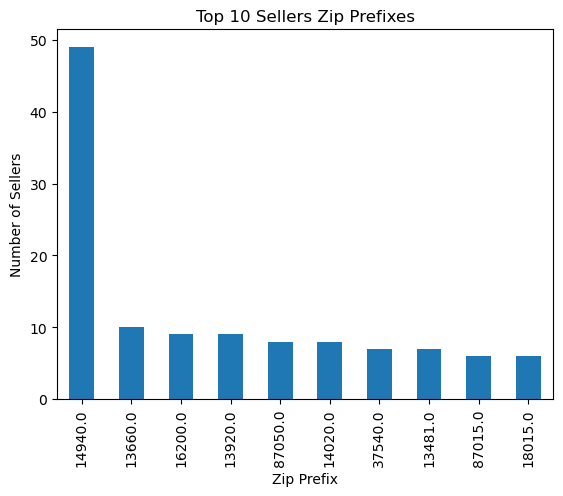

In [49]:
# Visualization
# Top 10 sellers zip prefixes 
sellers['seller_zip_code_prefix'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Sellers Zip Prefixes")
plt.xlabel("Zip Prefix")
plt.ylabel("Number of Sellers")
plt.show()

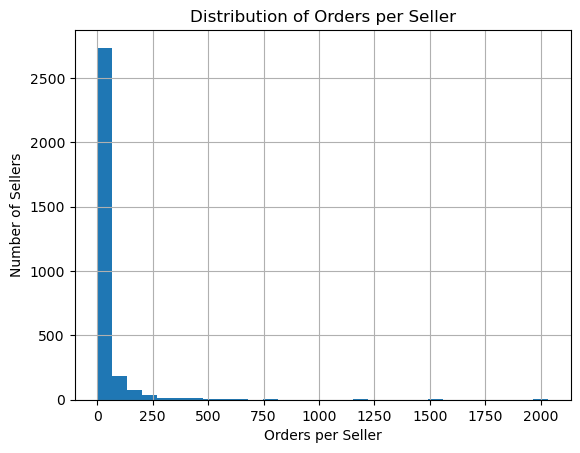

In [50]:
# Seller actvity distribution 
order_items['seller_id'].value_counts().hist(bins=30)
plt.title("Distribution of Orders per Seller")
plt.xlabel('Orders per Seller')
plt.ylabel("Number of Sellers")
plt.show()

In [51]:
# Geolocation Dataset
# Goal: Analyze geogrpahic mapping of customers and sellers, check the duplicates and validate zipcode prefixes
# Inspect structure 
geolocation.info()
geolocation.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
 3   geolocation_city             19015 non-null  object 
 4   geolocation_state            19015 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 742.9+ KB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,19015.000000,19015.000000,19015.000000,19015,19015
unique,NaN,NaN,NaN,5955,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,2652,6349
mean,42711.591901,-19.062087,-46.058008,NaN,NaN
std,30905.051745,7.319402,5.380751,NaN,NaN
min,1001.000000,-36.605374,-72.927296,NaN,NaN
25%,12721.500000,-23.564386,-49.000445,NaN,NaN
50%,38240.000000,-22.429252,-46.632544,NaN,NaN
75%,70656.500000,-15.615448,-43.255324,NaN,NaN


In [52]:
# Unique zip code prefixes
geolocation['geolocation_zip_code_prefix'].nunique()

19015

In [53]:
# check the anomalies 
geolocation[(geolocation['geolocation_lat']<-90) | (geolocation['geolocation_lat']>90)]
geolocation[(geolocation['geolocation_lng']<-180) | (geolocation['geolocation_lng']>180)]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


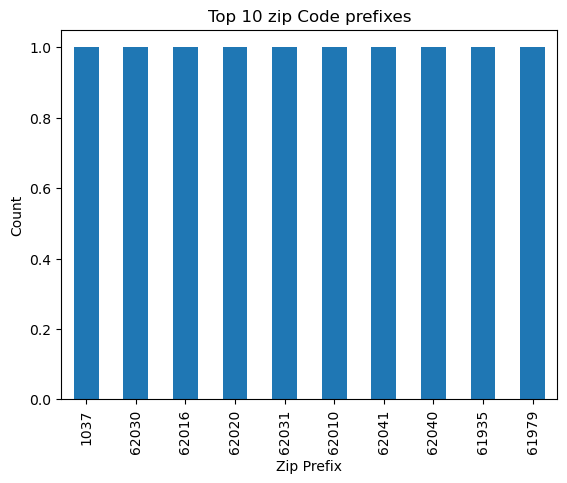

In [54]:
# Visualizations 
# Zip code frequency distribution 
geolocation['geolocation_zip_code_prefix'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 zip Code prefixes")
plt.xlabel("Zip Prefix")
plt.ylabel("Count")
plt.show()

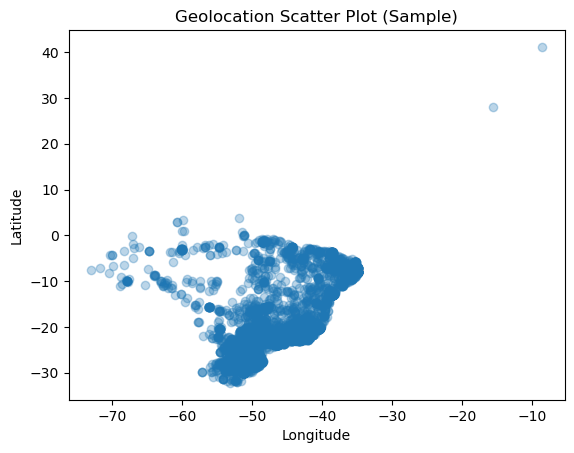

In [57]:
# Scatter Plot 
sample_geo = geolocation.sample(5000)
plt.scatter(sample_geo['geolocation_lng'], sample_geo['geolocation_lat'], alpha =0.3)
plt.title("Geolocation Scatter Plot (Sample)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# Integration Across Datasets
# Goal: bring all the datasets together to generate holistic insights.
#linking the customers, orders, products sellers, payments, reviews and geolocation


In [60]:
# Merge datasets Step by step 
# Orders + Customers 
orders_customers= orders.merge(customers, on='customer_id', how='left')

In [61]:

# Add Order Items
orders_items = orders_customers.merge(order_items, on='order_id', how='left')

# Add Products
orders_products = orders_items.merge(products, on='product_id', how='left')

# Add Sellers
orders_sellers = orders_products.merge(sellers, on='seller_id', how='left')

# Add Payments
orders_payments = orders_sellers.merge(payments, on='order_id', how='left')

# Add Reviews
orders_reviews = orders_payments.merge(reviews, on='order_id', how='left')

# Add Geolocation (via customer zip prefix)
final_dataset = orders_reviews.merge(
    geolocation[['geolocation_zip_code_prefix','geolocation_lat','geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)
